Saved → gantt_chart.png


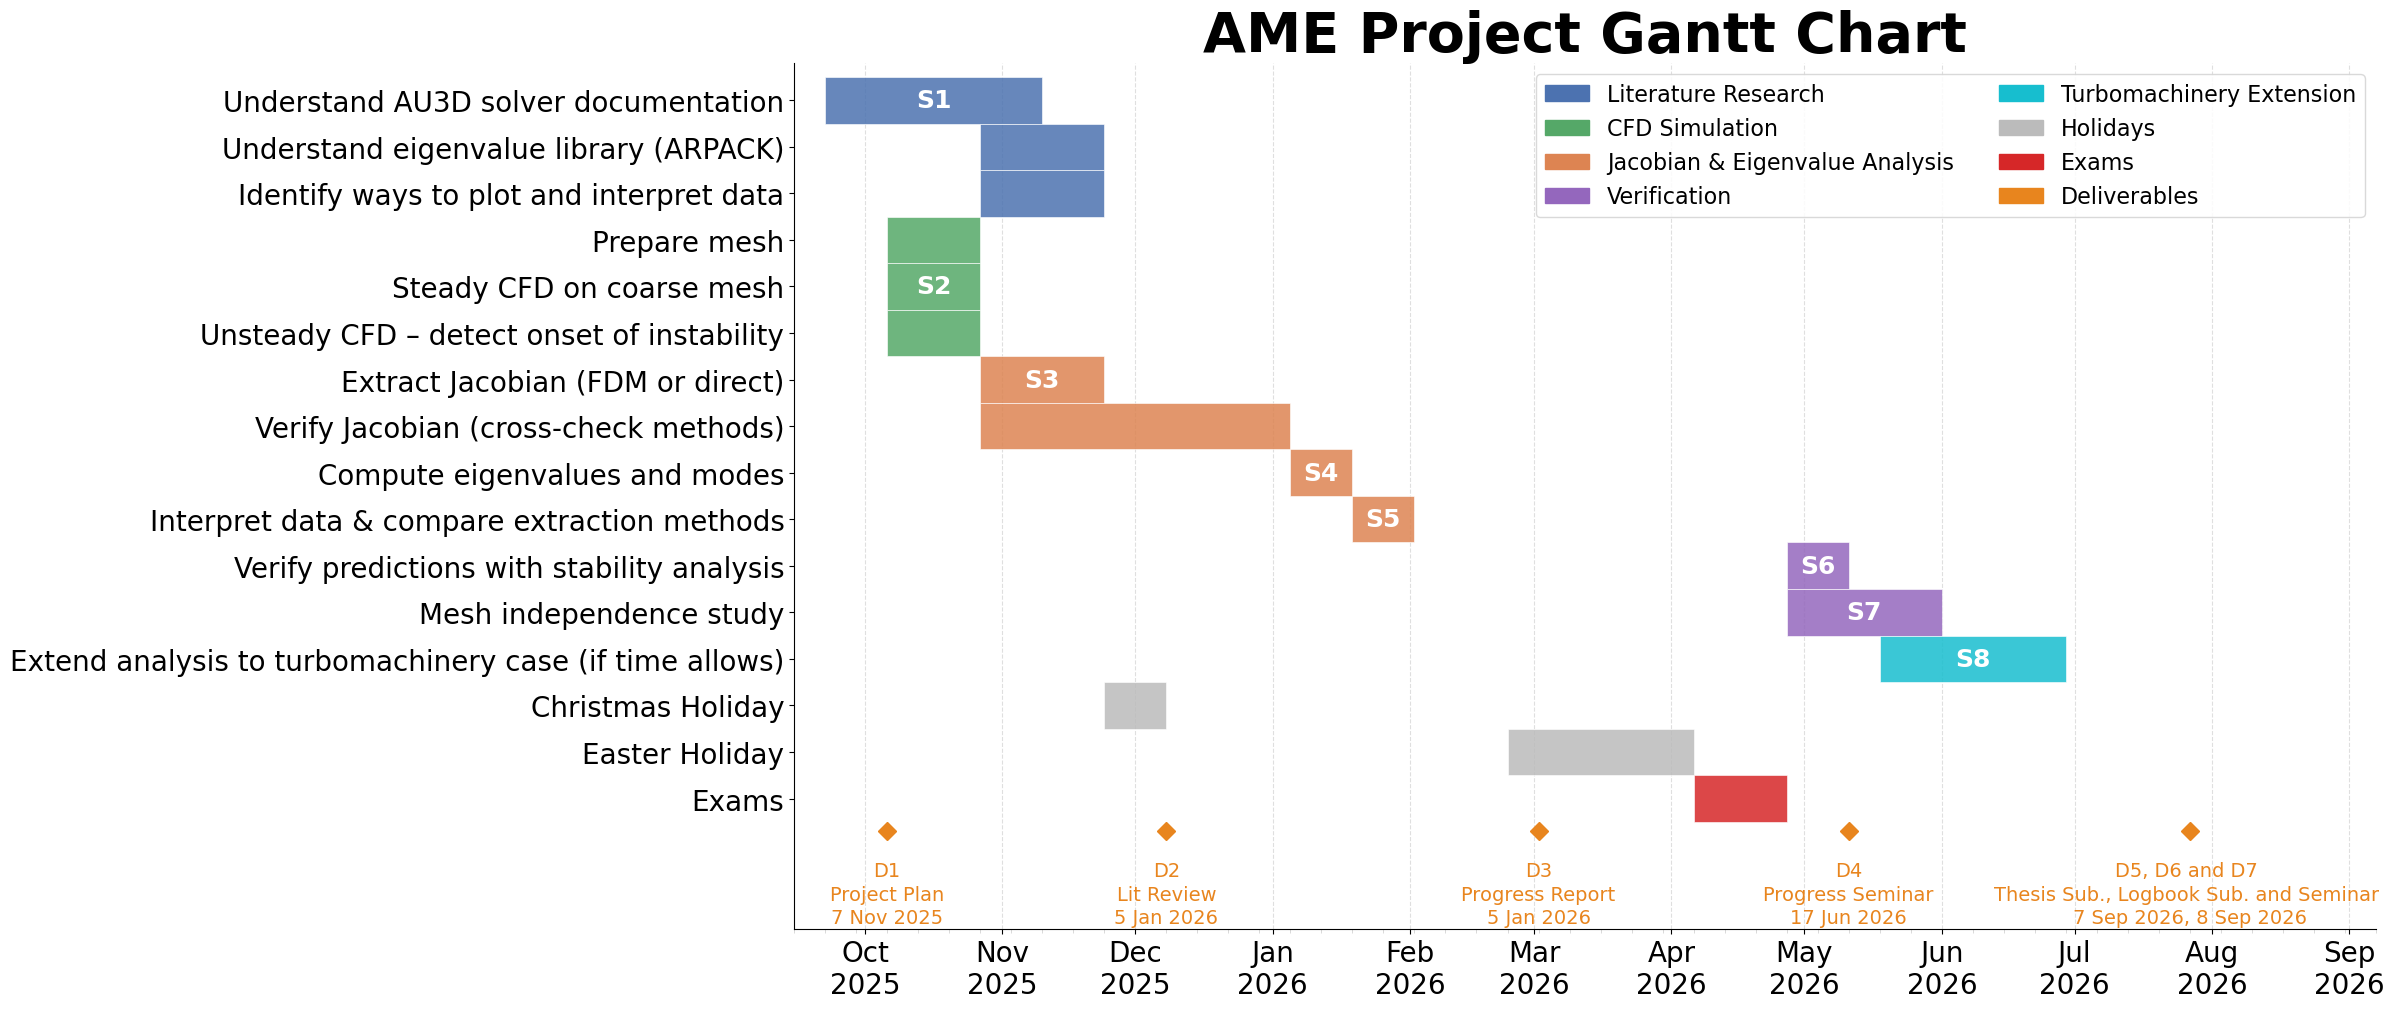

In [2]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime, date
import matplotlib.dates as mdates

# ─────────────────────────────────────────────
# PROJECT DATA  ← edit anything here
# ─────────────────────────────────────────────

PROJECT_TITLE = "AME Project Gantt Chart"

# Week-number → calendar date mapping (week 4 = first week of Oct 2025)
# Each task stores (start_week, end_week) — inclusive
# Category colours:  "lit"=blue, "cfd"=green, "jacobian"=orange,
#                    "verify"=purple, "turbomach"=teal, "holiday"=grey, "exam"=red

TASKS = [
    # ── Literature Research ──────────────────────────────────────────────────  
    {"label": "Understand AU3D solver documentation",              "start": 4, "end": 10, "cat": "lit",      "milestone": "S1"},
    {"label": "Understand eigenvalue library (ARPACK)",            "start": 9, "end": 12, "cat": "lit",      "milestone": None},
    {"label": "Identify ways to plot and interpret data",          "start": 9, "end": 12, "cat": "lit",      "milestone": None},

    # ── CFD Simulations ──────────────────────────────────────────────────────
    {"label": "Prepare mesh",                                    "start":  6, "end":  8, "cat": "cfd",      "milestone": None},
    {"label": "Steady CFD on coarse mesh",                       "start":  6, "end":  8, "cat": "cfd",      "milestone": "S2"},
    {"label": "Unsteady CFD – detect onset of instability",      "start":  6, "end":  8, "cat": "cfd",      "milestone": None},

    # ── Jacobian Extraction & Eigenvalue Analysis ────────────────────────────
    {"label": "Extract Jacobian (FDM or direct)",                "start": 9, "end": 12, "cat": "jacobian", "milestone": "S3"},
    {"label": "Verify Jacobian (cross-check methods)",           "start": 9, "end": 18, "cat": "jacobian", "milestone": None},
    {"label": "Compute eigenvalues and modes",                   "start": 19, "end": 20, "cat": "jacobian", "milestone": "S4"},
    {"label": "Interpret data & compare extraction methods",     "start": 21, "end": 22, "cat": "jacobian", "milestone": "S5"},

    # ── Verification ─────────────────────────────────────────────────────────
    {"label": "Verify predictions with stability analysis",      "start": 35, "end": 36, "cat": "verify",   "milestone": "S6"},
    {"label": "Mesh independence study",                         "start": 35, "end": 39, "cat": "verify",   "milestone": "S7"},

    # ── Turbomachinery Extension ──────────────────────────────────────────────
    {"label": "Extend analysis to turbomachinery case (if time allows)",     "start": 38, "end": 43, "cat": "turbomach","milestone": "S8"},
    # ── Holidays / Exams ──────────────────────────────────────────────────────
    {"label": "Christmas Holiday",                                             "start": 13, "end": 14, "cat": "holiday",  "milestone": None},
    {"label": "Easter Holiday",                                             "start": 26, "end": 31, "cat": "holiday",  "milestone": None},
    {"label": "Exams",                                                "start": 32, "end": 34, "cat": "exam",     "milestone": None},
]

# Deliverable diamonds  (week_number, label)
DELIVERABLES = [
    ( 6, "D1\nProject Plan\n7 Nov 2025"),
    (15, "D2\nLit Review\n5 Jan 2026"),
    (27, "D3\nProgress Report\n5 Jan 2026"),
    (37, "D4\nProgress Seminar\n17 Jun 2026"),
    (48, "D5, D6 and D7 \nThesis Sub., Logbook Sub. and Seminar \n7 Sep 2026, 8 Sep 2026")
]

# Week 1 = 13 Oct 2025  (Academic week 1 of 2025)
WEEK1_DATE = date(2025, 9, 1)

# ─────────────────────────────────────────────
# COLOUR MAP
# ─────────────────────────────────────────────
COLORS = {
    "lit":       "#4C72B0",
    "cfd":       "#55A868",
    "section":   "#888888",
    "jacobian":  "#DD8452",
    "verify":    "#9467BD",
    "turbomach": "#17BECF",
    "holiday":   "#BBBBBB",
    "exam":      "#D62728",
}

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────
def week_to_date(week_num):
    """Return the Monday of the given ISO-ish week (anchored to WEEK1_DATE)."""
    delta = (week_num - 1) * 7
    d = WEEK1_DATE + __import__('datetime').timedelta(days=delta)
    return datetime(d.year, d.month, d.day)

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────
fig_height = max(8, len(TASKS) * 0.45 + 3)
fig, ax = plt.subplots(figsize=(24, fig_height))
BAR_HEIGHT = 1

for i, task in enumerate(TASKS):
    y = len(TASKS) - i
    start_dt = week_to_date(task["start"])
    end_dt   = week_to_date(task["end"] + 1)          # +1 week so bar spans full week
    color    = COLORS.get(task["cat"], "#AAAAAA")
    alpha    = 0.45 if task["cat"] == "section" else 0.85

    ax.barh(y, (end_dt - start_dt).days, left=mdates.date2num(start_dt),
            height=BAR_HEIGHT, color=color, alpha=alpha, edgecolor="white", linewidth=0.5)

    # milestone badge inside bar
    if task["milestone"]:
        badge_x = mdates.date2num(start_dt) + (mdates.date2num(end_dt) - mdates.date2num(start_dt)) / 2
        ax.text(badge_x, y, task["milestone"], ha="center", va="center",
                fontsize=18, fontweight="bold", color="white")

# Deliverable diamonds
for week_num, label in DELIVERABLES:
    dx = mdates.date2num(week_to_date(week_num))
    ax.plot(dx, 0.3, marker="D", markersize=9, color="#E8851E", zorder=5)
    ax.text(dx, -0.35, label, ha="center", va="top",
            fontsize=14, color="#E8851E", linespacing=1.3)

# ── Y-axis labels ──
ax.set_yticks(range(1, len(TASKS) + 1))
ax.set_yticklabels([t["label"] for t in reversed(TASKS)], fontsize=20)
ax.set_ylim(0 - 1.8, len(TASKS) + 0.8)

# ── X-axis – monthly ticks ──
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
ax.tick_params(axis="x", which="minor", length=3, color="lightgrey")
ax.tick_params(axis="x", which="major", labelsize=20)

start_view = week_to_date(3)
end_view   = week_to_date(54)
ax.set_xlim(mdates.date2num(start_view), mdates.date2num(end_view))

# ── Grid ──
ax.xaxis.grid(True, which="major", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# ── Legend ──
legend_items = [
    mpatches.Patch(color=COLORS["lit"],       label="Literature Research"),
    mpatches.Patch(color=COLORS["cfd"],       label="CFD Simulation"),
    mpatches.Patch(color=COLORS["jacobian"],  label="Jacobian & Eigenvalue Analysis"),
    mpatches.Patch(color=COLORS["verify"],    label="Verification"),
    mpatches.Patch(color=COLORS["turbomach"], label="Turbomachinery Extension"),
    mpatches.Patch(color=COLORS["holiday"],   label="Holidays"),
    mpatches.Patch(color=COLORS["exam"],      label="Exams"),
    mpatches.Patch(color="#E8851E",           label="Deliverables"),
]
ax.legend(handles=legend_items, loc="upper right", fontsize=16, ncol=2,
          framealpha=0.85, edgecolor="lightgrey")

# ── Title & styling ──
ax.set_title(PROJECT_TITLE, fontsize=40, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

OUTPUT = "gantt_chart.png"

plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"Saved → {OUTPUT}")
plt.show() 

Saved → gantt_chart_updated.png


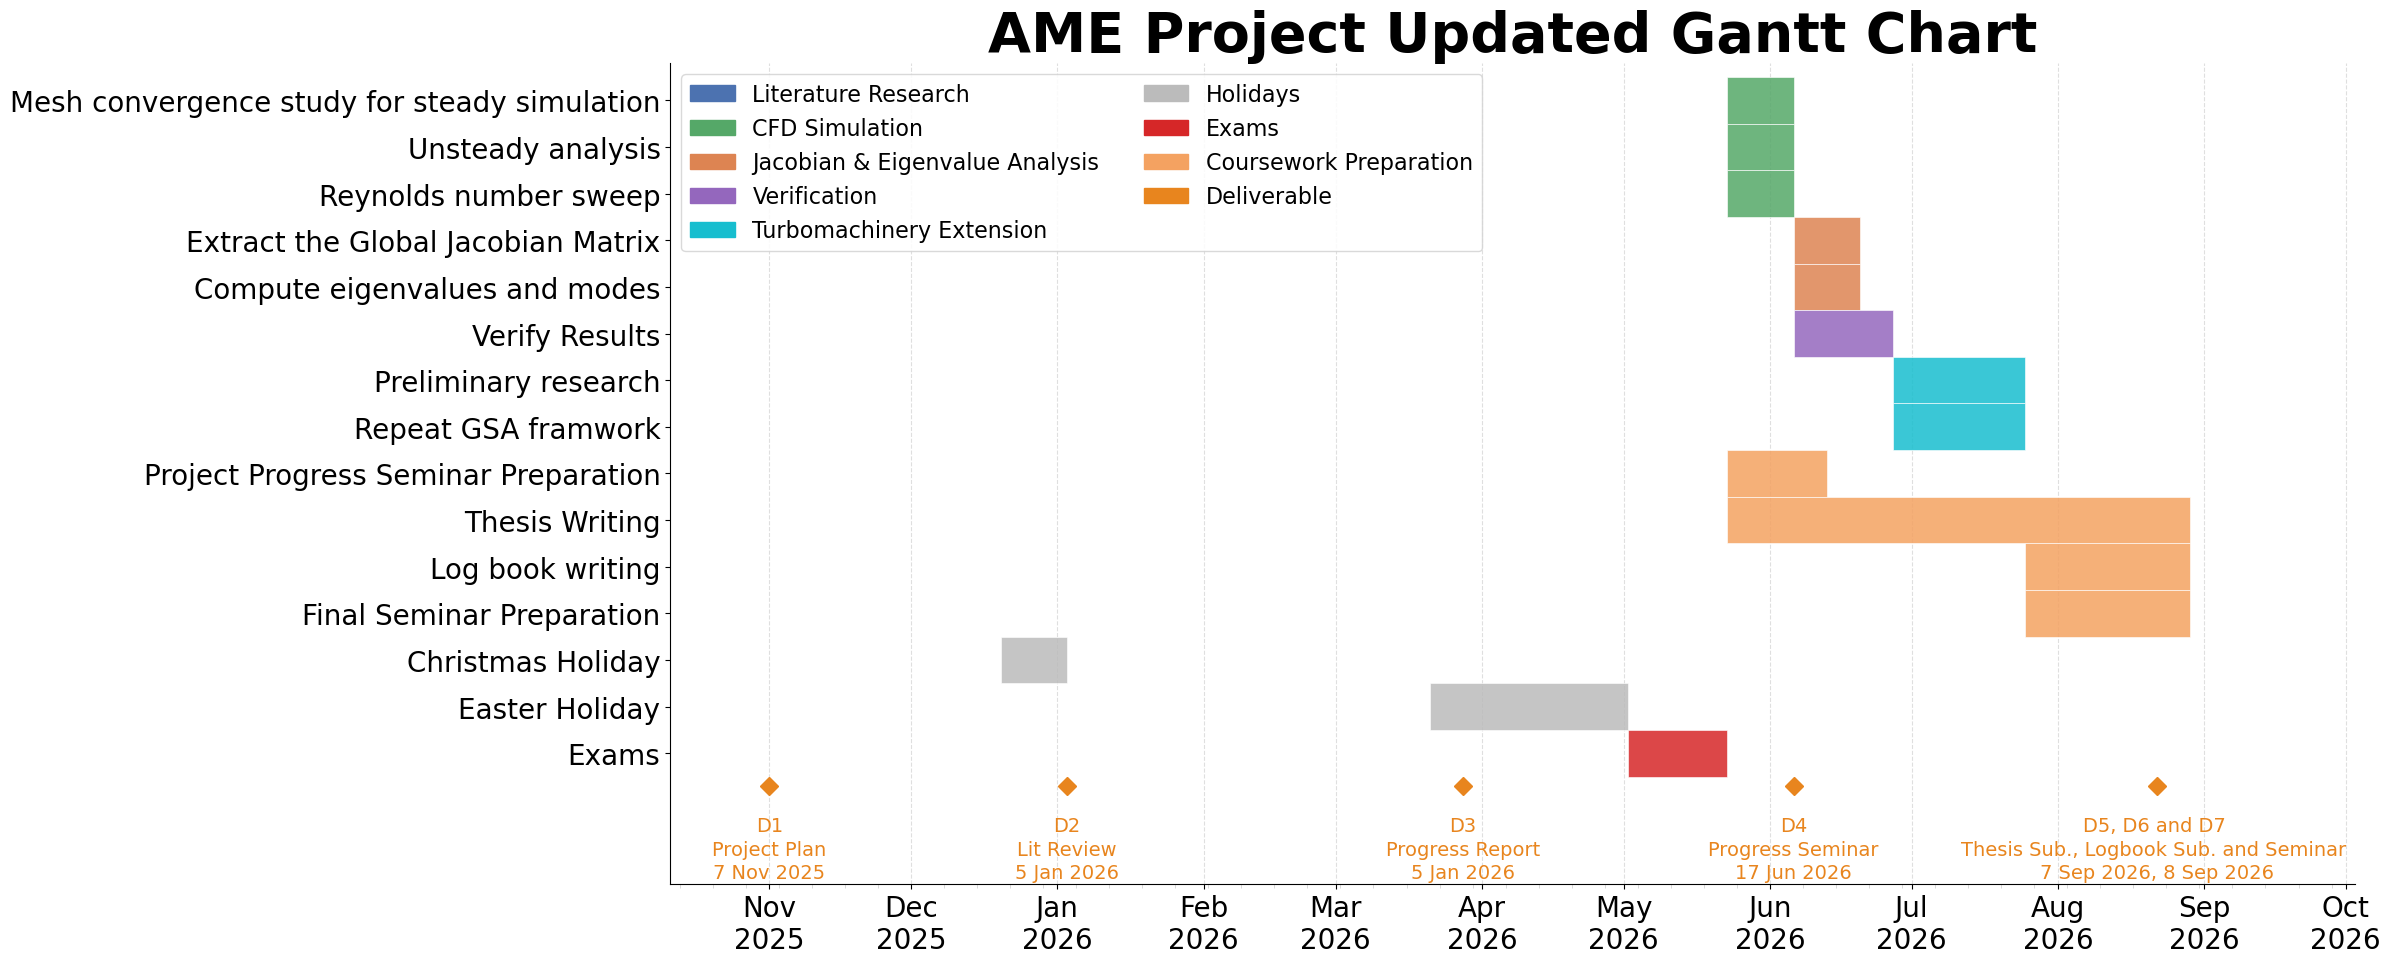

In [3]:
# updated Gantt Chart 2026

# ─────────────────────────────────────────────
# PROJECT DATA  ← edit anything here
# ─────────────────────────────────────────────

PROJECT_TITLE = "AME Project Updated Gantt Chart"

# Week-number → calendar date mapping (week 4 = first week of Oct 2025)
# Each task stores (start_week, end_week) — inclusive
# Category colours:  "lit"=blue, "cfd"=green, "jacobian"=orange,
#                    "verify"=purple, "turbomach"=teal, "holiday"=grey, "exam"=red

TASKS = [
    # ── CFD Simulations ──────────────────────────────────────────────────────
    {"label": "Mesh convergence study for steady simulation",         "start":  35, "end":  36, "cat": "cfd",      "milestone": None},
    {"label": "Unsteady analysis",                                    "start":  35, "end":  36, "cat": "cfd",      "milestone": None},
    {"label": "Reynolds number sweep",                                    "start":  35, "end":  36, "cat": "cfd",      "milestone": None},

    # ── Jacobian Extraction & Eigenvalue Analysis ─────────────────────────────
    {"label": "Extract the Global Jacobian Matrix",                   "start": 37, "end": 38, "cat": "jacobian", "milestone": None},
    {"label": "Compute eigenvalues and modes",                   "start": 37, "end": 38, "cat": "jacobian", "milestone": None},

    # ── Verification ─────────────────────────────────────────────────────────
    {"label": "Verify Results",                                       "start": 37, "end": 39, "cat": "verify",  "milestone": None},
    # ── Turbomachinery Extension ──────────────────────────────────────────────
    {"label": "Preliminary research",                                  "start": 40, "end": 43, "cat": "turbomach","milestone": None},
    {"label": "Repeat GSA framwork",                                   "start": 40, "end": 43, "cat": "turbomach","milestone": None},
    # report writing and course working preparation
    {"label": "Project Progress Seminar Preparation",                         "start": 35, "end": 37, "cat": "coursework",  "milestone": None},
    {"label": "Thesis Writing",                                               "start": 35, "end": 48, "cat": "coursework",  "milestone": None},
    {"label": "Log book writing",                                             "start": 44, "end": 48, "cat": "coursework",  "milestone": None},
    {"label": "Final Seminar Preparation",                                    "start": 44, "end": 48, "cat": "coursework",  "milestone": None},
    # ── Holidays / Exams ──────────────────────────────────────────────────────
    {"label": "Christmas Holiday",                                    "start": 13, "end": 14, "cat": "holiday",  "milestone": None},
    {"label": "Easter Holiday",                                       "start": 26, "end": 31, "cat": "holiday",  "milestone": None},
    {"label": "Exams",                                                "start": 32, "end": 34, "cat": "exam",     "milestone": None},
]

# Deliverable diamonds  (week_number, label)
DELIVERABLES = [
    ( 6, "D1\nProject Plan\n7 Nov 2025"),
    (15, "D2\nLit Review\n5 Jan 2026"),
    (27, "D3\nProgress Report\n5 Jan 2026"),
    (37, "D4\nProgress Seminar\n17 Jun 2026"),
    (48, "D5, D6 and D7 \nThesis Sub., Logbook Sub. and Seminar \n7 Sep 2026, 8 Sep 2026")
]

# Week 1 = 13 Oct 2025  (Academic week 1 of 2025)
WEEK1_DATE = date(2025, 9, 27)

# ─────────────────────────────────────────────
# COLOUR MAP
# ─────────────────────────────────────────────
COLORS = {
    "lit":       "#4C72B0",
    "cfd":       "#55A868",
    "section":   "#888888",
    "jacobian":  "#DD8452",
    "verify":    "#9467BD",
    "turbomach": "#17BECF",
    "holiday":   "#BBBBBB",
    "exam":      "#D62728",
    "coursework": "#F4A261",
}

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────
def week_to_date(week_num):
    """Return the Monday of the given ISO-ish week (anchored to WEEK1_DATE)."""
    delta = (week_num - 1) * 7
    d = WEEK1_DATE + __import__('datetime').timedelta(days=delta)
    return datetime(d.year, d.month, d.day)

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────
fig_height = max(8, len(TASKS) * 0.45 + 3)
fig, ax = plt.subplots(figsize=(24, fig_height))
BAR_HEIGHT = 1

for i, task in enumerate(TASKS):
    y = len(TASKS) - i
    start_dt = week_to_date(task["start"])
    end_dt   = week_to_date(task["end"] + 1)          # +1 week so bar spans full week
    color    = COLORS.get(task["cat"], "#AAAAAA")
    alpha    = 0.45 if task["cat"] == "section" else 0.85

    ax.barh(y, (end_dt - start_dt).days, left=mdates.date2num(start_dt),
            height=BAR_HEIGHT, color=color, alpha=alpha, edgecolor="white", linewidth=0.5)

    # milestone badge inside bar
    if task["milestone"]:
        badge_x = mdates.date2num(start_dt) + (mdates.date2num(end_dt) - mdates.date2num(start_dt)) / 2
        ax.text(badge_x, y, task["milestone"], ha="center", va="center",
                fontsize=18, fontweight="bold", color="white")

# Deliverable diamonds
for week_num, label in DELIVERABLES:
    dx = mdates.date2num(week_to_date(week_num))
    ax.plot(dx, 0.3, marker="D", markersize=9, color="#E8851E", zorder=5)
    ax.text(dx, -0.35, label, ha="center", va="top",
            fontsize=14, color="#E8851E", linespacing=1.3)

# ── Y-axis labels ──
ax.set_yticks(range(1, len(TASKS) + 1))
ax.set_yticklabels([t["label"] for t in reversed(TASKS)], fontsize=20)
ax.set_ylim(0 - 1.8, len(TASKS) + 0.8)

# ── X-axis – monthly ticks ──
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
ax.tick_params(axis="x", which="minor", length=3, color="lightgrey")
ax.tick_params(axis="x", which="major", labelsize=20)

start_view = week_to_date(3)
end_view   = week_to_date(54)
ax.set_xlim(mdates.date2num(start_view), mdates.date2num(end_view))

# ── Grid ──
ax.xaxis.grid(True, which="major", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# ── Legend ──
legend_items = [
    mpatches.Patch(color=COLORS["lit"],       label="Literature Research"),
    mpatches.Patch(color=COLORS["cfd"],       label="CFD Simulation"),
    mpatches.Patch(color=COLORS["jacobian"],  label="Jacobian & Eigenvalue Analysis"),
    mpatches.Patch(color=COLORS["verify"],    label="Verification"),
    mpatches.Patch(color=COLORS["turbomach"], label="Turbomachinery Extension"),
    mpatches.Patch(color=COLORS["holiday"],   label="Holidays"),
    mpatches.Patch(color=COLORS["exam"],      label="Exams"),
    mpatches.Patch(color=COLORS["coursework"], label="Coursework Preparation"),
    mpatches.Patch(color="#E8851E",           label="Deliverable"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=16, ncol=2,
          framealpha=0.85, edgecolor="lightgrey")

# ── Title & styling ──
ax.set_title(PROJECT_TITLE, fontsize=40, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

OUTPUT = "gantt_chart_updated.png"

plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"Saved → {OUTPUT}")
plt.show() 